# R5. Análisis intrínseco del corpus y su relación con los filtros de calidad

**Qué hace este cuaderno.** Analiza el corpus shiwilu **en función de lo que usan los filtros que aprueban o rechazan las oraciones generadas**
(Generate-then-Refine y Retrotraducción), y de ahí justifica qué técnicas de aumento se preseleccionan y cómo se aplican.
Todo lo que se mide aquí se calcula con **el mismo código y la misma ficha de marcadores** que usa la generación (`tecnicas_aumento/generate_then_refine.py`),
no con una copia aparte.

| Filtro | Qué exige a una oración generada | De dónde sale lo que exige | Sección |
|---|---|---|---|
| **Marcador** | Contener al menos un marcador de su intención (si la intención tiene marcadores) | `analisis_intrinseco/marcadores_fuentes.csv`, construida con **3 fuentes**: Valenzuela & Gussenhoven (2013) *JIPA*; Valenzuela (2012) *Voces shiwilu*; Valenzuela, Vásquez & Chota (2024) *Enciclopedia* | 2, 3, 4 |
| **Idioma** | Que el «shiwilu» no sea idéntico al español | Una regla simple | 5 |
| **Semántico** | Similitud con el centro de su intención (LaBSE) entre 0.20 y 0.995 | Las oraciones reales de entrenamiento de la intención | 6 |

Además, la sección 1 describe el corpus, la 7 muestra qué hicieron realmente los filtros con lo generado, la 8 los atajos superficiales (que justifican normalizar el texto),
la 9 las pistas estadísticas que recibió el prompt y la 10 la preselección de técnicas.

No requiere clave de API ni GPU. Calcula embeddings de LaBSE para las 700 oraciones (unos minutos la primera vez). Tablas y figuras se guardan en
`oe2_aumento_de_datos/analisis_intrinseco/resultados/analisis_filtros/`.

In [1]:
import re, sys, math, warnings
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 190); pd.set_option("display.max_colwidth", 75); pd.set_option("display.max_columns", 30)

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for p in (RAIZ, RAIZ / "oe2_aumento_de_datos" / "tecnicas_aumento"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import generate_then_refine as gtr                      # los MISMOS filtros y la misma ficha que usa la generación
from shiwilu.clasificacion import cargar_corpus, cargar_folds, extraer_embeddings
from shiwilu.rutas import MARCADORES_FUENTES_CSV, AUMENTO_SALIDA
from shiwilu.taxonomia import INTENCIONES

SAL = RAIZ / "oe2_aumento_de_datos" / "analisis_intrinseco" / "resultados" / "analisis_filtros"
FIG = SAL / "figuras"
FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
print("raíz:", RAIZ)
print("intenciones:", INTENCIONES)

raíz: C:\Lhia\Cursos Catolica\2026\TESIS\repo tesis\shiwilu-tesis
intenciones: ['SAL', 'EMO', 'PRG', 'REQUEST', 'AFI', 'NEG', 'DES']


## 1. Los datos y por qué aquí **no** hay una partición entrenamiento/desarrollo/prueba

Se analizan las **700 oraciones completas**. Una versión anterior de este análisis separaba un 70 % de entrenamiento (con 15 % de desarrollo y 15 % de prueba) y calculaba todo solo con ese 70 %.
Esa partición **no se usaba después en ningún experimento** (la evaluación usa 5 folds congelados), así que se eliminó, por tres razones:

1. **Lo que se analiza no se aprende del corpus.** Los marcadores salen de tres fuentes lingüísticas (la ficha `marcadores_fuentes.csv`), no de estadísticas del corpus; por lo tanto no hay nada
   que «filtrar» hacia el conjunto de prueba. Medir cuánto aparece cada marcador en las 700 oraciones es descripción, no entrenamiento.
2. **Lo que sí depende del entrenamiento se calcula con los folds reales.** El filtro semántico compara cada oración generada con el centro de las oraciones de entrenamiento *del fold*;
   en la sección 6 se calibra con exactamente esa regla: cada oración real se compara con el centro del entrenamiento del fold en que está de prueba.
3. **Se muestra la estabilidad por fold.** En las secciones 3 y 4 se informa cuánto varía cada cifra entre los 5 folds congelados, que son los que usan los experimentos.

La versión anterior se conserva sin cambios en `notebooks/historico/`. Sus tablas de patrones estadísticos (palabras y terminaciones) se mantienen en `resultados/tablas/` porque la generación
las leyó como «pistas» del prompt (ver sección 9).

In [2]:
df = cargar_corpus()
df["fold"] = cargar_folds(df)
print(f"{len(df)} oraciones; columnas: {list(df.columns)}")

PUNCT_BORDE = "¿?¡!.,;:\"()[]{}«»…—–\u2018\u2019\u201c\u201d"
def tokenizar(texto):
    toks = []
    for bruto in str(texto).split():
        t = bruto.strip(PUNCT_BORDE).lower()
        if any(ch.isalpha() for ch in t):
            toks.append(t)
    return toks

def mattr(tokens, ventana=25):
    if len(tokens) < ventana:
        return len(set(tokens)) / len(tokens) if tokens else np.nan
    return float(np.mean([len(set(tokens[i:i + ventana])) / ventana for i in range(len(tokens) - ventana + 1)]))

filas = []
for cat in INTENCIONES:
    textos = df.loc[df.intencion == cat, "shiwilu"]
    toks_por = [tokenizar(t) for t in textos]
    toks = [t for x in toks_por for t in x]
    frec = Counter(toks)
    filas.append({"intencion": cat, "n_oraciones": len(textos), "palabras_por_oracion": round(np.mean([len(x) for x in toks_por]), 2),
                  "tokens": len(toks), "tipos": len(frec), "TTR": round(len(frec) / len(toks), 3), "MATTR": round(mattr(toks), 3),
                  "prop_hapax": round(sum(1 for c in frec.values() if c == 1) / len(frec), 3)})
perfil = pd.DataFrame(filas).set_index("intencion")
perfil.to_csv(SAL / "perfil_corpus.csv")
print("Perfil del corpus completo (700 oraciones)")
display(perfil)

dup_shi = int(df.shiwilu.duplicated(keep=False).sum()); dup_par = int(df.duplicated(["shiwilu", "intencion"]).sum())
print(f"\nEnunciados shiwilu repetidos (filas): {dup_shi}; pares (shiwilu, intención) repetidos: {dup_par}")
print("Por eso las oraciones con el mismo texto se mantienen juntas en un mismo fold.\n")
tam = df.groupby("fold").size().rename("oraciones_de_prueba").to_frame()
tam["oraciones_de_entrenamiento"] = len(df) - tam.oraciones_de_prueba
display(tam)

700 oraciones; columnas: ['id', 'espanol', 'shiwilu', 'intencion', 'fuente', 'fold']
Perfil del corpus completo (700 oraciones)


,n_oraciones,palabras_por_oracion,tokens,tipos,TTR,MATTR,prop_hapax
intencion,,,,,,,
SAL,100,1.74,174,92,0.529,0.728,0.707
EMO,100,1.68,168,103,0.613,0.820,0.825
PRG,100,1.53,153,113,0.739,0.835,0.823
REQUEST,100,1.62,162,124,0.765,0.842,0.871
AFI,100,1.80,180,73,0.406,0.631,0.753
NEG,100,1.65,165,100,0.606,0.742,0.830
DES,100,1.59,159,124,0.780,0.863,0.855



Enunciados shiwilu repetidos (filas): 69; pares (shiwilu, intención) repetidos: 39
Por eso las oraciones con el mismo texto se mantienen juntas en un mismo fold.



,oraciones_de_prueba,oraciones_de_entrenamiento
fold,,
0,137,563
1,133,567
2,149,551
3,140,560
4,141,559


## 2. Las tres fuentes y la ficha de marcadores que usa el filtro

El filtro de marcador no usa estadísticas del corpus: usa la ficha **`marcadores_fuentes.csv`**, curada a mano a partir de tres fuentes:

- **JIPA:** Valenzuela & Gussenhoven (2013), *Shiwilu (Jebero)*, Journal of the International Phonetic Association 43(1).
- **Voces:** Valenzuela (2012), *Voces shiwilu: 400 años de resistencia lingüística en Jeberos* (parte II, textos).
- **Enciclopedia:** Valenzuela, Vásquez & Chota (2024), capítulo «Shiwilu» de la *Enciclopedia de las lenguas indígenas u originarias del Perú*.

Cada forma lleva la página y un **nivel de evidencia**: **A** = una fuente la describe explícitamente con su función (se usa en el filtro y en el prompt); **B** = solo aparece dentro de oraciones de ejemplo, sin
describirla como marcador (no se usa); **C** = la fuente la describe con otra función, no la de la intención (no se usa). El filtro solo emplea las filas con `usar = si`.

In [3]:
fi = pd.read_csv(MARCADORES_FUENTES_CSV)
fi["JIPA"] = fi.fuente.str.contains("Gussenhoven")
fi["Voces"] = fi.fuente.str.contains("Voces")
fi["Enciclopedia"] = fi.fuente.str.contains("Enciclopedia")
print(f"{len(fi)} formas en la ficha; {int((fi.usar == 'si').sum())} se usan en el filtro y en el prompt (usar = si)\n")
display(fi[["id", "categoria", "forma", "funcion", "paginas", "nivel", "usar", "JIPA", "Voces", "Enciclopedia"]])

print("Formas por nivel y uso:")
display(pd.crosstab(fi.nivel, fi.usar))
print("Formas que respalda cada fuente (una forma puede tener varias):")
display(fi[["JIPA", "Voces", "Enciclopedia"]].sum().rename("formas").to_frame().T)
res = (fi.groupby("categoria").agg(formas_en_la_ficha=("forma", "size"), formas_usadas_en_el_filtro=("usar", lambda s: int((s == "si").sum()))).reindex(INTENCIONES).fillna(0).astype(int))
res["el_filtro_exige_marcador"] = res.formas_usadas_en_el_filtro > 0
print("Qué intenciones tienen marcadores que el filtro pueda exigir:")
display(res)
fi.to_csv(SAL / "ficha_marcadores_por_fuente.csv", index=False)

17 formas en la ficha; 10 se usan en el filtro y en el prompt (usar = si)



,id,categoria,forma,funcion,paginas,nivel,usar,JIPA,Voces,Enciclopedia
0,NEG-01,NEG,i'n,negacion ('no'); ante 3SG se ve como i'ñi,JIPA p.100; Voces p.65,A,si,True,True,False
1,NEG-02,NEG,-inpu',sufijo negativo (nominal); tras vocal se ve como i'npu',JIPA p.102; Voces p.73,A,si,True,True,False
2,PRG-01,PRG,a'cha,particula interrogativa,JIPA p.103; Voces p.77,A,si,True,True,False
3,PRG-02,PRG,a'ta',particula interrogativa (sorpresa),JIPA p.103; Voces p.77,A,si,True,True,False
4,PRG-03,PRG,eñnupa,palabra interrogativa lexica ('donde'),Voces p.63,B,no,False,True,False
5,PRG-04,PRG,ma'pu'si'pa',palabra interrogativa lexica ('como pues'),Voces p.65; Enciclopedia p.148,B,no,False,True,True
6,PRG-05,PRG,ma'nen / ma'lusa',"palabra interrogativa lexica ('que cosa', 'que tipo')",Voces p.77; JIPA p.103,B,no,True,True,False
7,REQ-01,REQUEST,-(k)er',imperativo de 2SG (palabra terminada en -er'/-ker'),JIPA p.99; Voces p.75,A,si,True,True,False
8,REQ-02,REQUEST,enchuku','vamos' (hortativo),Voces p.67,B,no,False,True,False
9,EMO-01,EMO,chi,"particula de pena o sorpresa (habla masculina), palabra independiente",JIPA p.102; Voces p.76,A,si,True,True,False


Formas por nivel y uso:


usar,no,si
nivel,,
A,0,10
B,4,0
C,3,0


Formas que respalda cada fuente (una forma puede tener varias):


,JIPA,Voces,Enciclopedia
formas,13,14,1


Qué intenciones tienen marcadores que el filtro pueda exigir:


,formas_en_la_ficha,formas_usadas_en_el_filtro,el_filtro_exige_marcador
categoria,,,
SAL,0,0,False
EMO,3,2,True
PRG,5,2,True
REQUEST,2,1,True
AFI,5,3,True
NEG,2,2,True
DES,0,0,False


**Lectura.** Solo cinco de las siete intenciones tienen marcadores utilizables (NEG, PRG, REQUEST, EMO y AFI). **SAL y DES no tienen ninguno** en las fuentes, así que el filtro de marcador **aprueba
automáticamente todo** lo generado para ellas. Esto condiciona la composición del texto sintético (sección 7).

## 3. ¿Aparecen esos marcadores en el corpus?

Se busca cada forma de la ficha en las 700 oraciones **con su propia expresión regular (`patron`)**, la misma que aplica el filtro. Se mide la **cobertura dentro de su intención** (qué porcentaje de las oraciones de
esa intención lo contiene), la cobertura en el resto y un log-odds suavizado (cuánto más probable es en su intención; valores altos = marcador específico). Se agrega cuánto varía la cobertura entre los 5 folds.

In [4]:
def norm_apostrofe(t):
    return re.sub("[\u2019\u02bc\u2018\u00b4`]", "'", str(t).lower())     # igual que gtr.filtro_marcador

textos_norm = df.shiwilu.map(norm_apostrofe)
filas = []
for r in fi.itertuples():
    pat = re.compile(r.patron)
    m = textos_norm.map(lambda t: bool(pat.search(t)))
    en = df.intencion == r.categoria
    a, b, n1 = int((m & en).sum()), int((m & ~en).sum()), int(en.sum())
    n2 = len(df) - n1
    lo = math.log((a + .5) / (n1 - a + .5)) - math.log((b + .5) / (n2 - b + .5))
    cov_folds = [(m & en & (df.fold == f)).sum() / max(1, (en & (df.fold == f)).sum()) for f in range(5)]
    filas.append({"id": r.id, "intencion": r.categoria, "forma": r.forma, "nivel": r.nivel, "usar": r.usar,
                  "oraciones_con_la_forma": a + b, "en_su_intencion": a, "cobertura_en_su_intencion": round(a / n1, 3),
                  "cobertura_en_el_resto": round(b / n2, 3), "log_odds": round(lo, 2),
                  "cobertura_min_por_fold": round(min(cov_folds), 3), "cobertura_max_por_fold": round(max(cov_folds), 3)})
mc = pd.DataFrame(filas)
mc.to_csv(SAL / "marcadores_en_el_corpus.csv", index=False)
print("Marcadores de la ficha en el corpus (las filas con usar = si son las que exige el filtro)")
display(mc)

Marcadores de la ficha en el corpus (las filas con usar = si son las que exige el filtro)


,id,intencion,forma,nivel,usar,oraciones_con_la_forma,en_su_intencion,cobertura_en_su_intencion,cobertura_en_el_resto,log_odds,cobertura_min_por_fold,cobertura_max_por_fold
0,NEG-01,NEG,i'n,A,si,81,62,0.62,0.032,3.88,0.450,0.682
1,NEG-02,NEG,-inpu',A,si,13,12,0.12,0.002,4.03,0.045,0.200
2,PRG-01,PRG,a'cha,A,si,10,10,0.10,0.000,4.94,0.048,0.150
3,PRG-02,PRG,a'ta',A,si,6,1,0.01,0.008,0.49,0.000,0.043
4,PRG-03,PRG,eñnupa,B,no,1,1,0.01,0.000,2.90,0.000,0.053
5,PRG-04,PRG,ma'pu'si'pa',B,no,0,0,0.00,0.000,1.79,0.000,0.000
6,PRG-05,PRG,ma'nen / ma'lusa',B,no,3,2,0.02,0.002,2.32,0.000,0.059
7,REQ-01,REQUEST,-(k)er',A,si,57,30,0.30,0.045,2.20,0.261,0.391
8,REQ-02,REQUEST,enchuku',B,no,0,0,0.00,0.000,1.79,0.000,0.000
9,EMO-01,EMO,chi,A,si,0,0,0.00,0.000,1.79,0.000,0.000


**Lectura.** Cinco formas del nivel A están **presentes y concentradas** en su intención: `i'n` (62 % de las NEG), `-inpu'` (12 % de las NEG), `a'cha` (10 % de las PRG), `-(k)er'` (30 % de las REQUEST) y `ajá` (28 % de las AFI),
con log-odds altos y cobertura que varía poco entre folds. En cambio, las partículas de pesar **`chi` y `ten` (EMO)**, `ahã` y `untana` (AFI) **no aparecen en ninguna oración** y `a'ta'` (PRG) aparece una sola vez en PRG.
Es decir: la literatura las documenta, pero las oraciones del corpus (traducidas desde el español) no las usan. Eso importa en la sección siguiente.

### 3b. ¿El patrón del filtro captura las variantes de la forma?

Las fuentes indican que la partícula `a'cha` **se liga y se fusiona** con la palabra anterior cuando esta termina en `a` (por ejemplo `samellusa'cha`). El patrón de la ficha para esa forma es `a'cha`, que **no captura la variante fusionada** `…'cha`.
Se mide cuántas oraciones reales de PRG se perderían por eso.

In [5]:
variantes = {"a'cha (patrón de la ficha)": r"a'cha", "'cha al final de palabra (incluye la forma fusionada)": r"'cha(?=\W|$)"}
filas = []
for nombre, pat in variantes.items():
    m = textos_norm.map(lambda t: bool(re.search(pat, t)))
    filas.append({"patrón": nombre, "PRG": int((m & (df.intencion == "PRG")).sum()), "otras intenciones": int((m & (df.intencion != "PRG")).sum())})
t3b = pd.DataFrame(filas)
t3b.to_csv(SAL / "variantes_no_capturadas_acha.csv", index=False)
display(t3b)

,patrón,PRG,otras intenciones
0,a'cha (patrón de la ficha),10,0
1,'cha al final de palabra (incluye la forma fusionada),19,3


**Lectura.** Con la forma fusionada aparecen casi el doble de oraciones de PRG con la partícula (19 frente a 10). Es una limitación del patrón actual, que hace el filtro **más estricto de lo que describen las fuentes**; no se modificó porque
cambiaría qué oraciones están aprobadas en las cachés ya generadas (se puede reaplicar sin API con `tecnicas_aumento/refiltrar_marcadores.py`).

## 4. ¿Cuántas oraciones **reales** cumplirían el filtro de marcador?

Si el filtro de marcador se aplicara a las oraciones reales del corpus, ¿cuántas pasarían? Esto mide qué tan exigente es el filtro respecto de cómo se habla (o se escribió) realmente en el corpus.
Se usa la función `filtro_marcador` de la generación, sin modificarla.

In [6]:
mar = gtr.cargar_marcadores_validados()
df["pasa_marcador"] = [gtr.filtro_marcador(t, mar.get(c, [])) for t, c in zip(df.shiwilu, df.intencion)]
t4 = df.groupby("intencion").pasa_marcador.mean().reindex(INTENCIONES).round(3).rename("reales_que_cumplirian_el_filtro").to_frame()
for f in range(5):
    t4[f"fold{f}"] = df[df.fold == f].groupby("intencion").pasa_marcador.mean().reindex(INTENCIONES).round(2)
t4["marcadores_exigidos"] = [", ".join(m["forma"] for m in mar.get(c, [])) or "(ninguno)" for c in INTENCIONES]
t4.to_csv(SAL / "filtro_marcador_sobre_reales.csv")
display(t4)

,reales_que_cumplirian_el_filtro,fold0,fold1,fold2,fold3,fold4,marcadores_exigidos
intencion,,,,,,,
SAL,1.00,1.00,1.00,1.00,1.00,1.00,(ninguno)
EMO,0.00,0.00,0.00,0.00,0.00,0.00,"chi, ten"
PRG,0.11,0.05,0.15,0.11,0.06,0.17,"a'cha, a'ta'"
REQUEST,0.30,0.26,0.27,0.26,0.31,0.39,-(k)er'
AFI,0.28,0.22,0.35,0.30,0.25,0.29,"ajá, ahã, untana"
NEG,0.74,0.82,0.73,0.75,0.76,0.65,"i'n, -inpu'"
DES,1.00,1.00,1.00,1.00,1.00,1.00,(ninguno)


**Lectura.** Con la ficha de las tres fuentes, el filtro exigiría algo que **la mayoría de las oraciones reales no cumple**: solo el 74 % de las NEG, el 30 % de las REQUEST, el 28 % de las AFI y el 11 % de las PRG llevan
alguno de los marcadores, y **ninguna** de las EMO. SAL y DES pasan siempre porque no tienen marcadores. Por tanto, lo que el filtro aprueba es texto **más marcado que el corpus real**
(o, en EMO, texto con partículas que el corpus real no usa). Esto no demuestra por sí solo que dañe al clasificador, pero es una hipótesis concreta para explicar por qué el texto sintético de GtR se distingue del real
(ver capítulo de resultados).

## 5. Filtro de idioma

El filtro de idioma solo rechaza una oración si el «shiwilu» generado es **idéntico al español** (ignorando mayúsculas). Es deliberadamente laxo: no valida gramática ni ortografía. Se comprueba que no rechaza nada del corpus real.

In [7]:
idem = [not gtr.filtro_idioma(e, s) for e, s in zip(df.espanol, df.shiwilu)]
print(f"Oraciones reales rechazadas por el filtro de idioma: {sum(idem)} de {len(df)}")
print("Las oraciones sintéticas rechazadas por este filtro en las cachés se cuentan en la sección 7.")

Oraciones reales rechazadas por el filtro de idioma: 0 de 700
Las oraciones sintéticas rechazadas por este filtro en las cachés se cuentan en la sección 7.


## 6. Filtro semántico: ¿qué tan lejos del centro de su intención están las oraciones reales?

El filtro semántico calcula la similitud coseno (LaBSE) entre la oración generada y el **centro (promedio de vectores) de las oraciones reales de entrenamiento de su intención**, y la rechaza si queda
fuera de [0.20, 0.995] (por debajo = deriva de tema; por encima = casi idéntica a algo existente).
Para calibrarlo con datos reales se repite la misma regla con las oraciones reales: cada oración se compara con el centro del **entrenamiento del fold en que está de prueba** (nunca con su propio fold).

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Umbrales del filtro: [0.2, 0.995]


,minimo,p05,mediana,p95,maximo,reales_fuera_de_rango
intencion,,,,,,
SAL,0.381,0.543,0.748,0.842,0.875,0
EMO,0.389,0.474,0.720,0.859,0.898,0
PRG,0.591,0.728,0.838,0.913,0.926,0
REQUEST,0.415,0.459,0.682,0.808,0.853,0
AFI,0.485,0.545,0.705,0.806,0.872,0
NEG,0.350,0.526,0.792,0.895,0.923,0
DES,0.316,0.432,0.706,0.825,0.859,0


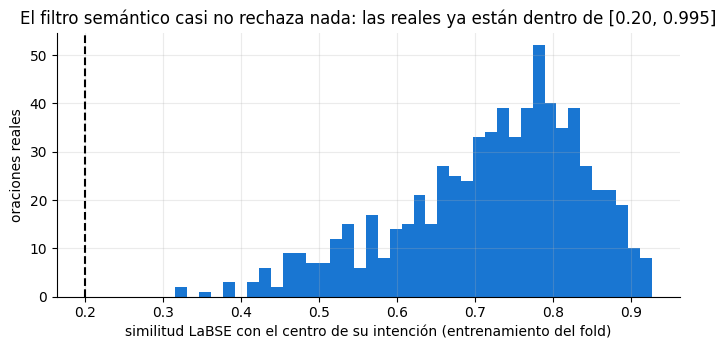

In [8]:
E = extraer_embeddings(df.shiwilu.tolist(), "labse")
E = E / np.linalg.norm(E, axis=1, keepdims=True)
sim = np.full(len(df), np.nan)
for f in range(5):
    tr = np.where(df.fold != f)[0]
    for cat in INTENCIONES:
        centro = E[[i for i in tr if df.intencion.iloc[i] == cat]].mean(axis=0)
        centro /= np.linalg.norm(centro)
        for i in np.where((df.fold == f) & (df.intencion == cat))[0]:
            sim[i] = float(E[i] @ centro)
df["sim_centro"] = sim
LO, HI = gtr.UMBRAL_SIMILITUD_MIN, gtr.UMBRAL_SIMILITUD_MAX
t6 = df.groupby("intencion").sim_centro.agg(minimo="min", p05=lambda s: s.quantile(.05), mediana="median", p95=lambda s: s.quantile(.95), maximo="max").reindex(INTENCIONES).round(3)
t6["reales_fuera_de_rango"] = df.assign(f=(df.sim_centro < LO) | (df.sim_centro > HI)).groupby("intencion").f.sum().reindex(INTENCIONES).astype(int)
print(f"Umbrales del filtro: [{LO}, {HI}]")
display(t6)
t6.to_csv(SAL / "filtro_semantico_sobre_reales.csv")
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(df.sim_centro, bins=40, color="#1976d2"); ax.axvline(LO, color="k", ls="--"); ax.set_xlabel("similitud LaBSE con el centro de su intención (entrenamiento del fold)"); ax.set_ylabel("oraciones reales")
ax.set_title("El filtro semántico casi no rechaza nada: las reales ya están dentro de [0.20, 0.995]")
fig.tight_layout(); fig.savefig(FIG / "filtro_semantico_reales.png", dpi=130); plt.show()

**Lectura.** Las oraciones reales quedan muy por encima del umbral inferior (0.20), de modo que **el filtro semántico es muy permisivo**: no es capaz de separar una oración bien formada de una mala dentro del mismo tema.
Esto se comprueba con lo generado en la sección siguiente.

## 7. Qué hicieron realmente los filtros con el texto generado

Las cachés de Generate-then-Refine guardan **todas** las candidatas de Claude con su estado (`aprobado` o `revisar_hablante_nativo`) y el filtro que falló. Se comparan dos versiones:

- **Con la ficha de las 3 fuentes** (la vigente): `salidas/en_linea_marcadores_fuentes/generate_then_refine/`.
- **Con la lista anterior de marcadores** (antes de adoptar la ficha): `salidas/en_linea/generate_then_refine/`.

Se usan los archivos `fold<N>_pool*.csv` (lo generado con todo el entrenamiento de cada fold, 120 por intención y fold). Retrotraducción no pasa por el filtro de marcador: se filtra con idioma y similitud al evaluar.

Con la ficha de las 3 fuentes (30 archivos, 4182 candidatas)


,generadas,aprobadas_%,rechazo_marcador_%,rechazo_idioma_%,rechazo_semantico_%
intencion,,,,,
SAL,596,100.0,0.0,0.0,0.0
EMO,597,28.3,71.7,0.0,0.0
PRG,599,68.9,31.1,0.0,0.0
REQUEST,598,47.2,52.8,0.0,0.0
AFI,596,56.9,43.1,0.0,0.0
NEG,599,84.5,15.5,0.0,0.0
DES,597,100.0,0.0,0.0,0.0


Con la lista anterior de marcadores (30 archivos, 4185 candidatas)


,generadas,aprobadas_%,rechazo_marcador_%,rechazo_idioma_%,rechazo_semantico_%
intencion,,,,,
SAL,597,100.0,0.0,0.0,0.0
EMO,596,29.2,70.8,0.0,0.0
PRG,600,65.7,34.3,0.0,0.0
REQUEST,599,38.6,61.4,0.0,0.0
AFI,596,60.4,39.6,0.0,0.0
NEG,599,76.6,23.4,0.0,0.0
DES,598,100.0,0.0,0.0,0.0


,reales_que_cumplirian_el_filtro_%,generadas_aprobadas_%
intencion,,
SAL,100.0,100.0
EMO,0.0,28.3
PRG,11.0,68.9
REQUEST,30.0,47.2
AFI,28.0,56.9
NEG,74.0,84.5
DES,100.0,100.0


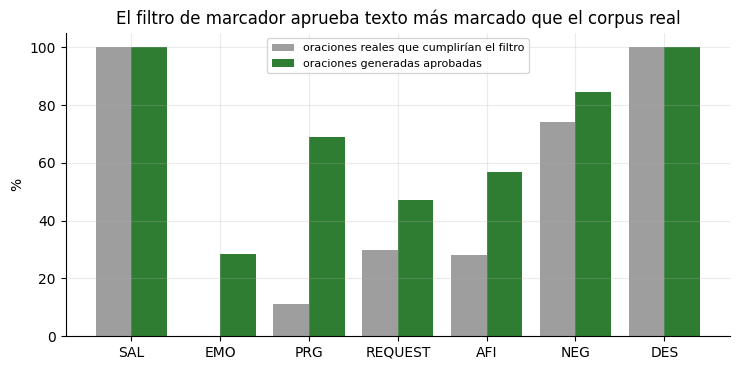

In [9]:
def cargar_cache(carpeta):
    fs = sorted((AUMENTO_SALIDA / carpeta).glob("fold*_pool*.csv"))
    d = pd.concat([pd.read_csv(f).assign(archivo=f.name) for f in fs], ignore_index=True)
    d["detalle_filtro"] = d.detalle_filtro.fillna("")
    return d

def resumen_filtros(d):
    g = d.groupby("intencion")
    return pd.DataFrame({
        "generadas": g.size(),
        "aprobadas_%": g.apply(lambda x: (x.estado_filtro == "aprobado").mean() * 100),
        "rechazo_marcador_%": g.apply(lambda x: x.detalle_filtro.str.contains("marcador").mean() * 100),
        "rechazo_idioma_%": g.apply(lambda x: x.detalle_filtro.str.contains("idioma").mean() * 100),
        "rechazo_semantico_%": g.apply(lambda x: x.detalle_filtro.str.contains("semantico").mean() * 100),
    }).reindex(INTENCIONES).round(1)

vig = cargar_cache("en_linea_marcadores_fuentes/generate_then_refine")
ant = cargar_cache("en_linea/generate_then_refine")
r_vig, r_ant = resumen_filtros(vig), resumen_filtros(ant)
print(f"Con la ficha de las 3 fuentes ({vig.archivo.nunique()} archivos, {len(vig)} candidatas)")
display(r_vig)
print(f"Con la lista anterior de marcadores ({ant.archivo.nunique()} archivos, {len(ant)} candidatas)")
display(r_ant)
r_vig.to_csv(SAL / "filtros_sobre_lo_generado_fuentes.csv"); r_ant.to_csv(SAL / "filtros_sobre_lo_generado_lista_anterior.csv")

comp = pd.DataFrame({"reales_que_cumplirian_el_filtro_%": (t4.reales_que_cumplirian_el_filtro * 100).round(1), "generadas_aprobadas_%": r_vig["aprobadas_%"]})
display(comp)
fig, ax = plt.subplots(figsize=(7.5, 3.8)); x = np.arange(7)
ax.bar(x - .2, comp["reales_que_cumplirian_el_filtro_%"], .4, color="#9e9e9e", label="oraciones reales que cumplirían el filtro")
ax.bar(x + .2, comp["generadas_aprobadas_%"], .4, color="#2e7d32", label="oraciones generadas aprobadas")
ax.set_xticks(x); ax.set_xticklabels(INTENCIONES); ax.set_ylabel("%"); ax.legend(fontsize=8); ax.set_title("El filtro de marcador aprueba texto más marcado que el corpus real")
fig.tight_layout(); fig.savefig(FIG / "filtro_marcador_reales_vs_generadas.png", dpi=130); plt.show()

In [10]:
# Ejemplos: qué se rechaza en EMO (la intención con menos aprobadas) y qué se aprueba
ej = vig[vig.intencion == "EMO"]
print("EMO rechazadas por marcador (la oración no trae «chi» ni «ten»):")
display(ej[ej.estado_filtro != "aprobado"][["espanol", "shiwilu", "detalle_filtro"]].head(5))
print("EMO aprobadas:")
display(ej[ej.estado_filtro == "aprobado"][["espanol", "shiwilu"]].head(5))

EMO rechazadas por marcador (la oración no trae «chi» ni «ten»):


,espanol,shiwilu,detalle_filtro
19,Qué alegría!,a'sakeklliu mushipa',marcador
20,Estoy triste.,enpu'ni wueinui,marcador
21,Me da miedo.,empu'ni ikerlli,marcador
22,"Ay, qué susto!",a'pinchi musu' ikerlli,marcador
23,Qué vergüenza!,enka'lliu enpu'nipa',marcador


EMO aprobadas:


,espanol,shiwilu
26,Qué lástima!,chi enpu'ni
30,Qué pena siento.,ten enpu'ni wueinui
37,Me da nostalgia.,chi enpu'nipa' wueinui
162,"¡Ay, qué pena!",ten enpu'ni
163,Qué vergüenza.,chi enpu'ni


**Lectura.**
- **Solo actúa el filtro de marcador.** El filtro de idioma y el semántico no rechazan prácticamente nada de lo generado (columnas en 0 %), consistente con lo que se vio en las secciones 5 y 6.
- **Las intenciones sin marcadores (SAL, DES) se aprueban al 100 %** y las que tienen marcadores raros en el corpus se aprueban poco (EMO ≈ 28 %, REQUEST ≈ 47 %). Esto explica el **desbalance** del texto sintético aprobado
  (muchas DES y SAL, pocas EMO, AFI y REQUEST) que se reporta en el capítulo de resultados.
- **Efecto de adoptar las tres fuentes.** Frente a la lista anterior, la ficha sube la aprobación de NEG (77 % a 85 %), REQUEST (39 % a 47 %) y PRG (66 % a 69 %) y la baja levemente en AFI (60 % a 57 %) y EMO (29 % a 28 %); el cambio es de **criterio** más que de volumen.
- **Texto «más marcado» que el real.** El 69 % de las PRG generadas pasa (llevan `a'cha`), pero solo el 11 % de las PRG reales lo lleva. Es decir, el prompt y el filtro empujan lo generado hacia los marcadores.

## 8. Atajos superficiales: por qué se normaliza el texto

Se mide qué rasgos del **texto crudo** (no del lenguaje) delatan una intención. El filtro de marcador y todo el aumento se aplican sobre texto normalizado para que el clasificador no aprenda estos atajos.

In [11]:
def cobertura(nombre, mascara):
    filas = []
    for cat in INTENCIONES:
        en = df.intencion == cat
        a = int((mascara & en).sum()); b = int(mascara.sum()) - a
        filas.append({"rasgo": nombre, "intencion": cat, "cobertura_en_su_intencion": round(a / en.sum(), 3), "cobertura_en_el_resto": round(b / (~en).sum(), 3)})
    return pd.DataFrame(filas)

sc = pd.concat([
    cobertura("tiene ¿ o ?", df.shiwilu.str.contains(r"[¿?]")),
    cobertura("tiene ¡ o !", df.shiwilu.str.contains(r"[¡!]")),
    cobertura("tiene alguna mayúscula", df.shiwilu.map(lambda t: any(ch.isupper() for ch in t))),
    cobertura("tiene una sola palabra", df.shiwilu.map(lambda t: len(tokenizar(t)) == 1)),
], ignore_index=True)
def riesgo(c, r):
    return "ALTO" if c >= .5 and r <= .05 else "MEDIO" if c >= .3 and r <= .1 else "BAJO" if c >= .15 and r <= .15 else "insignificante"
sc["riesgo"] = [riesgo(c, r) for c, r in zip(sc.cobertura_en_su_intencion, sc.cobertura_en_el_resto)]
sc.to_csv(SAL / "atajos_superficiales.csv", index=False)
display(sc[sc.riesgo != "insignificante"].sort_values(["riesgo", "cobertura_en_su_intencion"], ascending=[True, False]))

,rasgo,intencion,cobertura_en_su_intencion,cobertura_en_el_resto,riesgo
2,tiene ¿ o ?,PRG,1.00,0.030,ALTO
8,tiene ¡ o !,EMO,0.17,0.042,BAJO


**Lectura.** Los signos `¿?` cubren el 100 % de PRG y casi nada del resto: es un artefacto del formato de recolección, no lengua. **En la versión actual del corpus ya no hay mayúsculas** (todo está en minúsculas); en versiones anteriores
(según el historial del repositorio, entre 311 y 495 oraciones con mayúsculas) las mayúsculas también delataban intenciones (DES, PRG y REQUEST), y esa es una de las razones por las que se decidió evaluar con texto normalizado
(minúsculas, sin puntuación, sin tildes). La condición con `¿?` se evalúa como escenario aparte.

## 9. Pistas estadísticas del corpus que recibió el prompt (no son filtros)

Además de los marcadores de las fuentes, el prompt de Generate-then-Refine incluye, como **pistas no validadas**, las 8 palabras características y las 8 terminaciones más asociadas a cada intención. Esas listas
las leyó de `resultados/tablas/analisis_palabras_caracteristicas.csv` y `analisis_secuencias_finales.csv`, calculadas por la versión anterior de este análisis **con el 70 % de entrenamiento de la partición eliminada**.
Aquí se recalculan con las 700 oraciones y se comprueba cuánto cambian.

In [12]:
DIGRAFOS = ("ch", "ll", "sh")
def grafemas(p):
    p, out, i = str(p).lower(), [], 0
    while i < len(p):
        if p[i:i + 2] in DIGRAFOS: out.append(p[i:i + 2]); i += 2
        else: out.append(p[i]); i += 1
    return out

def asociacion(extractor, min_df=3, alpha=.5):
    n_cat = df.intencion.value_counts().to_dict(); N = len(df)
    por_patron = defaultdict(Counter)
    for t, c in zip(df.shiwilu, df.intencion):
        for p in set(extractor(t)):
            por_patron[p][c] += 1
    filas = []
    for p, lc in por_patron.items():
        tot = sum(lc.values())
        if tot < min_df: continue
        for c, a in lc.items():
            n1, b = n_cat[c], tot - a; n2 = N - n1
            lo = math.log((a + alpha) / (n1 - a + alpha)) - math.log((b + alpha) / (n2 - b + alpha))
            filas.append({"patron": p, "intencion": c, "cobertura_cat": a / n1, "cobertura_resto": b / n2, "log_odds": lo})
    return pd.DataFrame(filas)

pal = asociacion(lambda t: tokenizar(t))
sec = pd.concat([asociacion(lambda t, L=L: {"".join(grafemas(w)[-L:]) for w in tokenizar(t) if len(grafemas(w)) >= L}).assign(longitud=L) for L in (2, 3, 4, 5, 6)])
pal = pal[pal.cobertura_cat >= .05]; sec = sec[sec.cobertura_cat >= .05]
nuevo = {"palabras": pal, "terminaciones": sec}
filas = []
for nombre, arch in (("palabras", "analisis_palabras_caracteristicas.csv"), ("terminaciones", "analisis_secuencias_finales.csv")):
    viejo = pd.read_csv(SAL.parent / "tablas" / arch)
    viejo = viejo.sort_values("log_odds", ascending=False)
    for cat in INTENCIONES:
        v = set(viejo[viejo.intencion == cat].patron.head(gtr.N_PATRONES_CANDIDATOS).astype(str))
        n = set(nuevo[nombre][nuevo[nombre].intencion == cat].sort_values("log_odds", ascending=False).patron.head(gtr.N_PATRONES_CANDIDATOS).astype(str))
        filas.append({"tipo": nombre, "intencion": cat, "en_el_prompt_(70%)": len(v), "recalculado_(700)": len(n), "coinciden": len(v & n)})
t9 = pd.DataFrame(filas)
t9.to_csv(SAL / "pistas_estadisticas_comparacion.csv", index=False)
display(t9.pivot(index="intencion", columns="tipo", values="coinciden").reindex(INTENCIONES))
print(f"Pistas por intención y tipo: {gtr.N_PATRONES_CANDIDATOS}. La tabla muestra cuántas coinciden entre la versión que leyó el prompt y la recalculada con las 700 oraciones.")

tipo,palabras,terminaciones
intencion,,
SAL,5,7
EMO,6,7
PRG,2,7
REQUEST,1,8
AFI,7,8
NEG,3,7
DES,2,7


Pistas por intención y tipo: 8. La tabla muestra cuántas coinciden entre la versión que leyó el prompt y la recalculada con las 700 oraciones.


**Lectura.** Las pistas que leyó el prompt se calcularon con una partición que no coincide con los folds de evaluación, es decir, con oraciones que luego quedan de prueba en algunos folds. Como son estadísticas de palabras y terminaciones
frecuentes (no oraciones) y el texto generado nunca puede ser idéntico a una oración de prueba, el riesgo práctico es **bajo**, pero **metodológicamente es una limitación** y se declara. Una versión estricta calcularía esas pistas con el
entrenamiento de cada fold y regeneraría el texto (costo de la API); no se hizo.

## 10. Preselección de técnicas de aumento, justificada con lo anterior

**Criterios.** Obligatorios (excluyen): (1) que sirva con pocos datos; (2) que conserve los marcadores que identifican cada intención. De valoración (orientan): (3) variedad léxica, (4) independencia de rasgos superficiales,
(5) bajo riesgo de generar formas inexistentes.

| Hallazgo de este análisis | Qué implica para el aumento | Dónde se aplicó |
|---|---|---|
| Tres fuentes respaldan 10 marcadores de nivel A en 5 intenciones (secc. 2) | Las técnicas que generan texto deben **conservar el marcador** de su intención | Filtro de marcador (`usar = si`) y marcadores en el prompt de GtR |
| `i'n`, `-inpu'`, `a'cha`, `-(k)er'`, `ajá` están presentes y concentrados; `chi`, `ten`, `a'ta'`, `ahã`, `untana` no aparecen (secc. 3) | El filtro exigirá cosas que el corpus real no usa (EMO, AFI) | Se documenta como limitación; se evalúa su efecto en R6 |
| SAL y DES no tienen marcadores (secc. 2) | El filtro de marcador no puede controlar su calidad: pasan todo | Filtros de idioma y semántico (permisivos, secc. 5-6) |
| `¿?` delata PRG (y, en versiones previas del corpus, las mayúsculas delataban otras; secc. 8) | El aumento no puede depender de la puntuación; evaluar con y sin `¿?` | Texto normalizado; escenario con `¿?` aparte |
| 52 enunciados repetidos (secc. 1) | Deduplicar y agrupar antes de aumentar | Folds agrupados por texto; solo se aumenta el entrenamiento |
| AFI y SAL son las más repetitivas (TTR bajo, secc. 1) | Conviene una técnica que aporte variedad | Generate-then-Refine |
| Riesgo de formas inexistentes | Una técnica que no genere texto, y filtros para las que sí | Mixup (no genera texto); filtros en Retrotraducción y GtR |

**Resultado.** Se preseleccionan **tres técnicas**, cada una por un mecanismo complementario:

- **Retrotraducción** (Xie et al., 2020): aumenta el volumen a bajo costo; riesgo de «españolizar» y perder marcadores (`a'cha`); se aplica con filtros de idioma y similitud.
- **Generate-then-Refine** (Lin et al., 2024): la que más variedad léxica aporta; condicionada por la ficha de marcadores; se refina con los tres filtros.
- **Mixup** (Guo et al., 2019): no genera texto (interpola vectores de oraciones de la misma intención), por lo que no puede producir formas inexistentes ni depende de la puntuación.

Una cuarta candidata, la adaptación con XL-LoRA (Basoz et al., 2026), se descartó porque no es, en rigor, una técnica de aumento de datos aplicable a este diseño.

**Qué queda por medir en R6.** Esta preselección es un argumento, no una prueba: si cada técnica ayuda o no se mide con la validación cruzada. Los hallazgos de las secciones 4 y 7 (el filtro aprueba texto más marcado que el real y
desbalancea las intenciones) son hipótesis que el capítulo de resultados contrasta con el análisis de causas.

## Limitaciones

- **Corpus escrito**, sin entonación: la interrogación y el imperativo se distinguen también por prosodia en la lengua, y eso no es recuperable aquí.
- **Sin etiquetado morfológico:** las terminaciones y palabras características son candidatas estadísticas, no morfemas confirmados.
- **La ficha depende de tres fuentes** y de su interpretación: dos de ellas (JIPA, Voces) describen la lengua hablada o textos narrativos; las partículas de pesar pueden no aparecer en oraciones traducidas desde el español.
- **El filtro de idioma y el semántico son permisivos** (secciones 5 y 6); la calidad lingüística del texto generado **no se valida** sin un hablante nativo.
- **Las pistas estadísticas del prompt** se calcularon con la partición 70/15/15 anterior, no con los folds (sección 9).
- Los marcadores de nivel B y C **no se usan** en los filtros; ampliar la ficha cambiaría qué se aprueba (se puede reaplicar el filtro sin API con `tecnicas_aumento/refiltrar_marcadores.py`).

In [13]:
print("Tablas y figuras guardadas en:", SAL)
sorted(p.name for p in SAL.rglob("*") if p.is_file())

Tablas y figuras guardadas en: C:\Lhia\Cursos Catolica\2026\TESIS\repo tesis\shiwilu-tesis\oe2_aumento_de_datos\analisis_intrinseco\resultados\analisis_filtros


['atajos_superficiales.csv',
 'ficha_marcadores_por_fuente.csv',
 'filtro_marcador_reales_vs_generadas.png',
 'filtro_marcador_sobre_reales.csv',
 'filtro_semantico_reales.png',
 'filtro_semantico_sobre_reales.csv',
 'filtros_sobre_lo_generado_fuentes.csv',
 'filtros_sobre_lo_generado_lista_anterior.csv',
 'marcadores_en_el_corpus.csv',
 'perfil_corpus.csv',
 'pistas_estadisticas_comparacion.csv',
 'variantes_no_capturadas_acha.csv']